[*********************100%***********************]  6 of 6 completed



--- PORTFOLIO RISK SUMMARY ---


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Ticker,,,,
XOM,0.2737,0.2666,0.8766,-0.2051
JPM,0.1975,0.2435,0.6469,-0.3877
SPY,0.1362,0.1709,0.5631,-0.2450
AAPL,0.1884,0.2749,0.5398,-0.3336
JNJ,0.1109,0.1673,0.4236,-0.1841
MSFT,0.1381,0.2642,0.3712,-0.3715


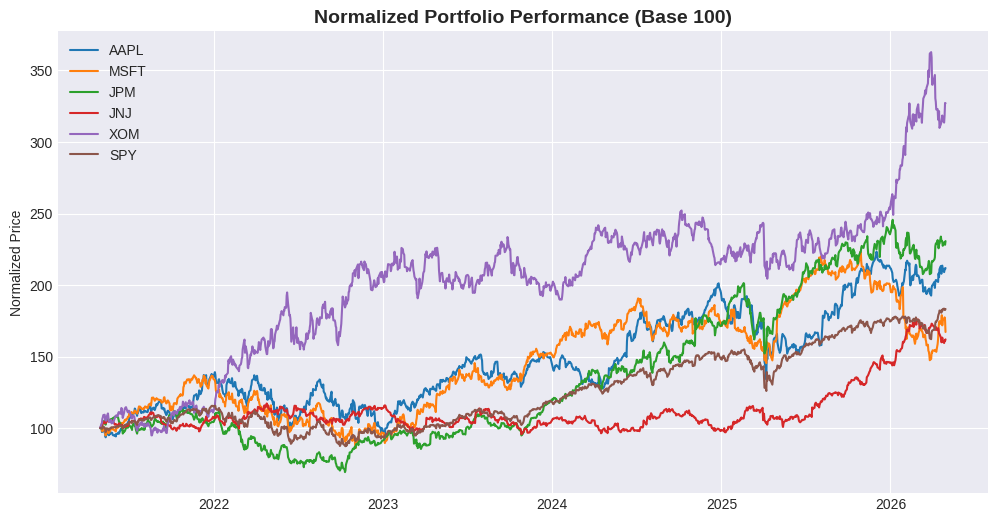

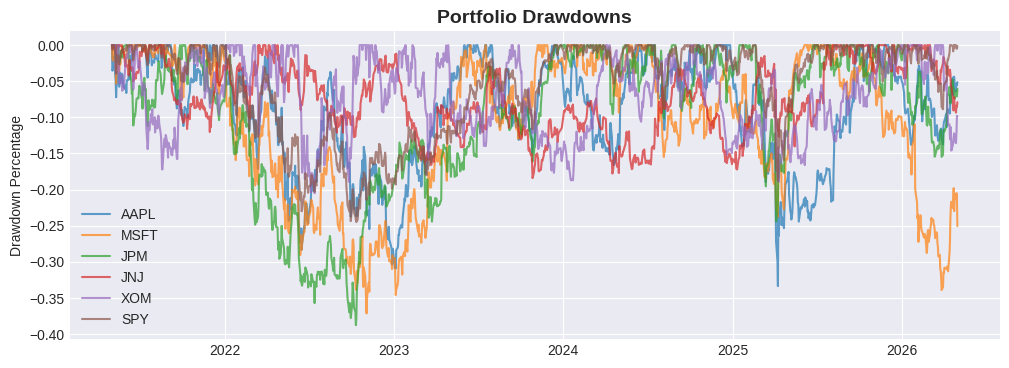

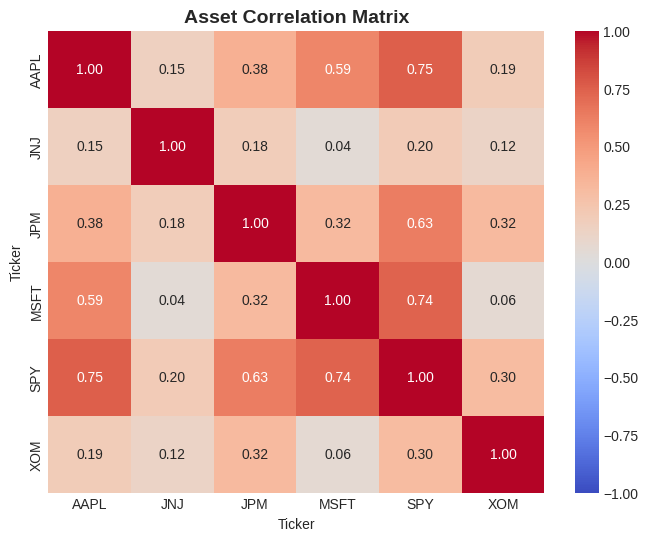

In [2]:
# 1. Install and Import Libraries
!pip install yfinance -q
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 2. Define Portfolio and Fetch Data (Last 5 Years)
tickers = ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM', 'SPY']
print(f"Downloading data for: {', '.join(tickers)}...")
data = yf.download(tickers, period='5y')['Close']

# 3. Calculate Returns
daily_returns = data.pct_change().dropna()
monthly_returns = data.resample('M').last().pct_change().dropna()

# 4. Calculate Risk & Performance Metrics
# Assuming a 4% risk-free rate for the Sharpe Ratio
risk_free_rate = 0.04

# Annualized Return
annual_return = daily_returns.mean() * 252

# Annualized Volatility
annual_volatility = daily_returns.std() * np.sqrt(252)

# Sharpe Ratio
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

# Maximum Drawdown
cumulative_returns = (1 + daily_returns).cumprod()
peak = cumulative_returns.cummax()
drawdown = (cumulative_returns - peak) / peak
max_drawdown = drawdown.min()

# 5. Compile the Risk Summary Table
risk_metrics = pd.DataFrame({
    'Annualized Return': annual_return,
    'Annualized Volatility': annual_volatility,
    'Sharpe Ratio': sharpe_ratio,
    'Max Drawdown': max_drawdown
}).round(4)

print("\n--- PORTFOLIO RISK SUMMARY ---")
display(risk_metrics.sort_values(by='Sharpe Ratio', ascending=False))

# 6. Visualizations
plt.style.use('seaborn-v0_8-darkgrid')

# Chart A: Normalized Price Performance (Base 100)
normalized_price = (data / data.iloc[0]) * 100
plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(normalized_price.index, normalized_price[ticker], label=ticker, linewidth=1.5)
plt.title('Normalized Portfolio Performance (Base 100)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Price')
plt.legend(loc='upper left')
plt.show()

# Chart B: Maximum Drawdown Over Time
plt.figure(figsize=(12, 4))
for ticker in tickers:
    plt.plot(drawdown.index, drawdown[ticker], label=ticker, alpha=0.7)
plt.title('Portfolio Drawdowns', fontsize=14, fontweight='bold')
plt.ylabel('Drawdown Percentage')
plt.legend(loc='lower left')
plt.show()

# Chart C: Asset Correlation Matrix
plt.figure(figsize=(8, 6))
correlation_matrix = daily_returns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Asset Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()